In [1]:
import pandas as pd
import math
from ta.momentum import KAMAIndicator
from ta.trend import SMAIndicator
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
#print(sns.__version__)

import bb_ama_f

In [2]:
quality = bb_ama_f.algorithm_calc(ticker='Si', type='filtered')
quality

{'yr rate': 0.2015220050049351,
 'dd mean': -0.018252633145559017,
 'dd max': -0.29015199727831853,
 'correlation': 0.26048899661566766,
 'deals': 4514,
 'records': 56407,
 'flat ratio': 0.6861027886609818}

In [3]:
-quality['yr rate']*quality['correlation']/quality['dd mean']

2.875983123152031

In [4]:
data = bb_ama_f.algorithm_calc(ticker='Si', type='filtered', brief=False)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


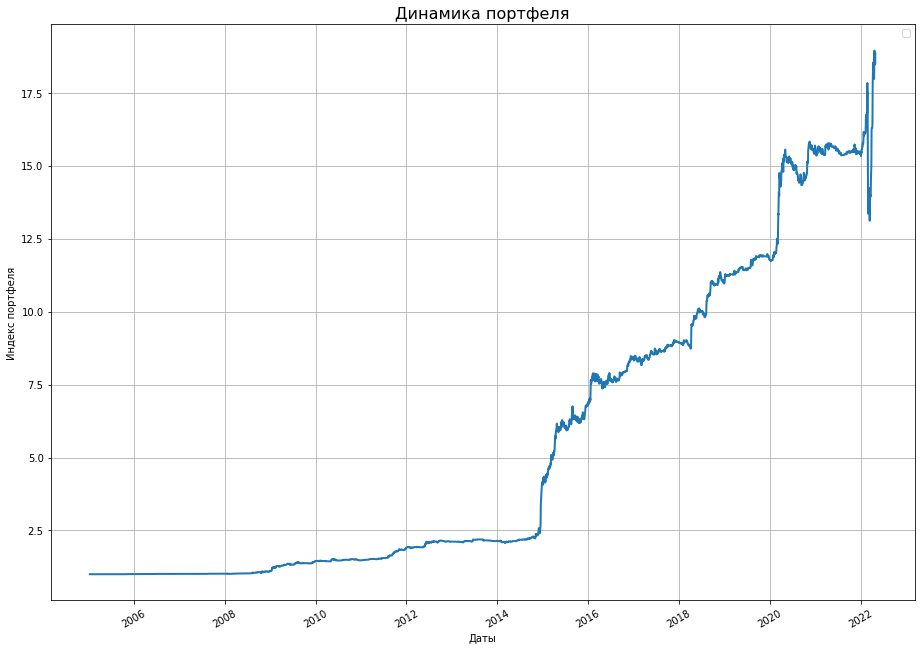

In [5]:
pf = data.groupby('date')['portfolio'].mean()

#визуализация графиков
fig = plt.figure(figsize=(12, 8))
axes = fig.add_axes([0, 0, 1, 1])
axes.plot(pf, lw=2)

#установка параметров отображения
axes.set_title('Динамика портфеля', fontsize=16)
axes.set_xlabel('Даты')
axes.set_ylabel('Индекс портфеля')
axes.xaxis.set_tick_params(rotation=30)
axes.grid()
axes.legend();

In [6]:
period = 14*21*3 #столько часов в квартале
data['m_q'] = data['portfolio'].diff(period)/data['portfolio'].shift(period)*100
period = 14*21*12 #столько часов в квартале
data['m_y'] = data['portfolio'].diff(period)/data['portfolio'].shift(period)*100

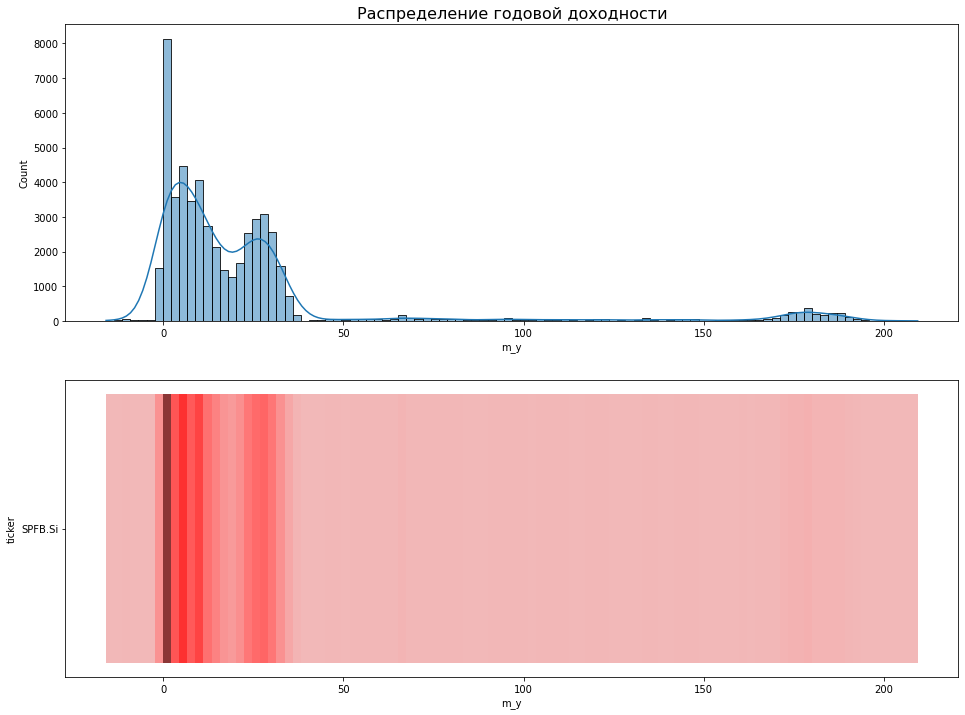

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12))
sns.histplot(
    data=data,
    x='m_y',
    bins=100,
    kde=True,
    ax=axes[0],
);
axes[0].set_title('Распределение годовой доходности', fontsize=16)
sns.histplot(
    data=data,
    x='m_y',
    y='ticker',
    bins=100,
    color='red',
    ax=axes[1]
);

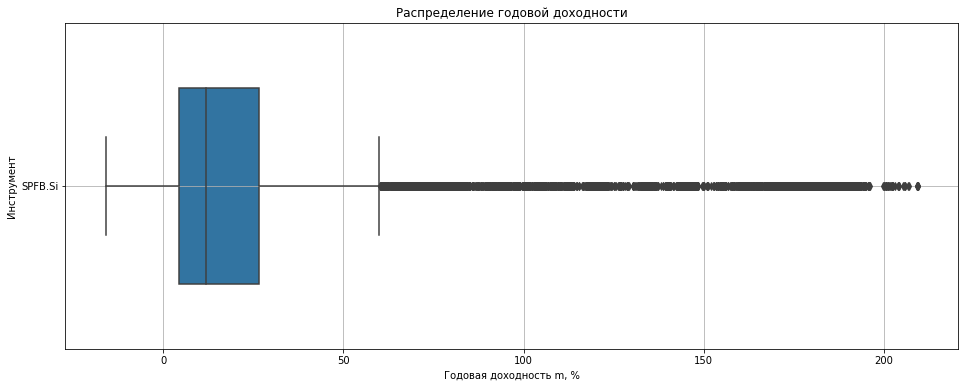

In [8]:
fig = plt.figure(figsize=(16, 6))
boxplot = sns.boxplot(
    data=data,
    y='ticker',
    x='m_y',
    orient='h',
    width=0.6
)
boxplot.set_title('Распределение годовой доходности');
boxplot.set_xlabel('Годовая доходность m, %');
boxplot.set_ylabel('Инструмент');
boxplot.grid()

In [57]:
result_list = []
c_ama_fast = 1 
for i in range(10, 101, 5):
    for j in range (10, 201, 5):
        quality = bb_ama_f.algorithm_calc('Si', c_ama_fast, i, j, type='unfiltered')
        q_value = -quality['yr rate']*quality['correlation']/quality['dd mean']
        # создаём кортеж
        item = (i, j, q_value) 
        result_list.append(item) 
# создаём вспомогательную таблицу
quality_df1 = pd.DataFrame(
    result_list,
    columns=['ama_slow', 'ama_int', 'quality']
)

c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encounte

In [58]:
result_list = []
c_ama_fast = 2 
for i in range(10, 101, 5):
    for j in range (10, 201, 5):
        quality = bb_ama_f.algorithm_calc('Si', c_ama_fast, i, j, type='unfiltered')
        q_value = -quality['yr rate']*quality['correlation']/quality['dd mean']
        # создаём кортеж
        item = (i, j, q_value) 
        result_list.append(item) 
# создаём вспомогательную таблицу
quality_df2 = pd.DataFrame(
    result_list,
    columns=['ama_slow', 'ama_int', 'quality']
)

c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encounte

In [70]:
result_list = []
c_ama_fast = 3 
for i in range(10, 101, 5):
    for j in range (10, 201, 5):
        quality = bb_ama_f.algorithm_calc('Si', c_ama_fast, i, j, type='unfiltered')
        q_value = -quality['yr rate']*quality['correlation']/quality['dd mean']
        # создаём кортеж
        item = (i, j, q_value) 
        result_list.append(item) 
# создаём вспомогательную таблицу
quality_df3 = pd.DataFrame(
    result_list,
    columns=['ama_slow', 'ama_int', 'quality']
)

c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\
c:\IDE\FORTS BB AMA H1 F\bb_ama_f.py:148: RuntimeWarning: invalid value encountered in double_scalars
  "yr rate": data['portfolio'].iloc[-1]**(14*21*12/data['portfolio'].count())-1,\


In [71]:
result_list = []
c_ama_fast = 4 
for i in range(10, 101, 5):
    for j in range (10, 201, 5):
        quality = bb_ama_f.algorithm_calc('Si', c_ama_fast, i, j, type='unfiltered')
        q_value = -quality['yr rate']*quality['correlation']/quality['dd mean']
        # создаём кортеж
        item = (i, j, q_value) 
        result_list.append(item) 
# создаём вспомогательную таблицу
quality_df4 = pd.DataFrame(
    result_list,
    columns=['ama_slow', 'ama_int', 'quality']
)

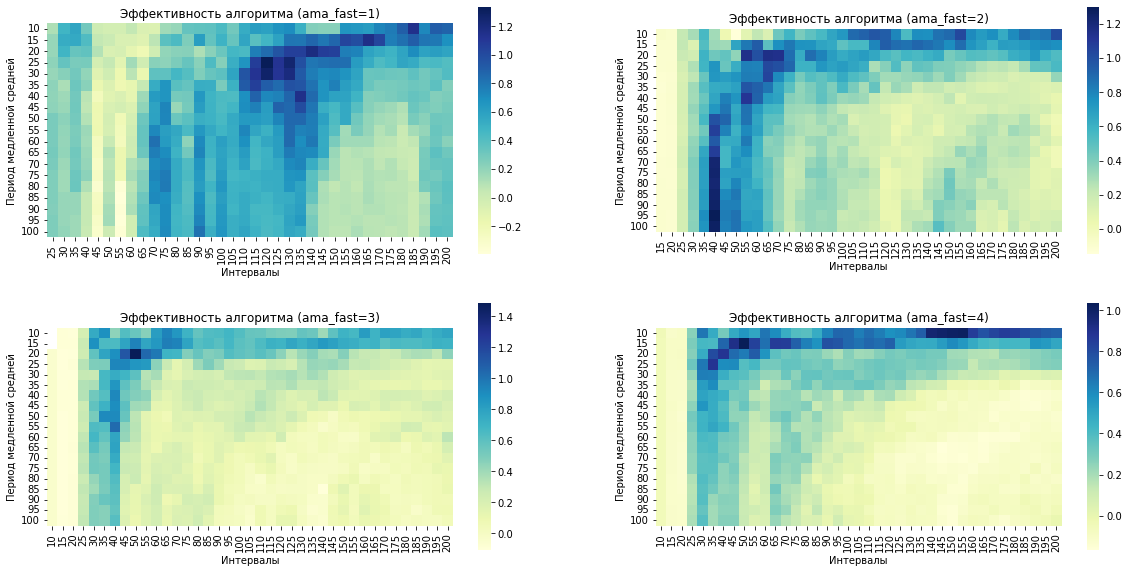

In [72]:
#строим сводную таблицу
pivot1 = quality_df1.pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot2 = quality_df2.pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot3 = quality_df3.pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)
pivot4 = quality_df4.pivot_table(
    values='quality',
    columns='ama_int',
    index='ama_slow'
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

heatmap1 = sns.heatmap(data=pivot1, cmap='YlGnBu', annot=False, square=True, ax=axes[0,0])
heatmap1.set_title('Эффективность алгоритма (ama_fast=1)');
heatmap1.set_xlabel('Интервалы');
heatmap1.set_ylabel('Период медленной средней');

heatmap2 = sns.heatmap(data=pivot2, cmap='YlGnBu', annot=False, square=True, ax=axes[0,1])
heatmap2.set_title('Эффективность алгоритма (ama_fast=2)');
heatmap2.set_xlabel('Интервалы');
heatmap2.set_ylabel('Период медленной средней');

heatmap3 = sns.heatmap(data=pivot3, cmap='YlGnBu', annot=False, square=True, ax=axes[1,0])
heatmap3.set_title('Эффективность алгоритма (ama_fast=3)');
heatmap3.set_xlabel('Интервалы');
heatmap3.set_ylabel('Период медленной средней');

heatmap4 = sns.heatmap(data=pivot4, cmap='YlGnBu', annot=False, square=True, ax=axes[1,1])
heatmap4.set_title('Эффективность алгоритма (ama_fast=4)');
heatmap4.set_xlabel('Интервалы');
heatmap4.set_ylabel('Период медленной средней');

In [73]:
print(quality_df1['quality'].max())
print(quality_df2['quality'].max())
print(quality_df3['quality'].max())
print(quality_df4['quality'].max())

1.33541007356581
1.2993442190019482
1.4838021969019866
1.0331464348980557
